# Flight Demand Analysis

**Цель:** анализ 300 000+ бронирований авиабилетов индийского рынка — выявить паттерны ценообразования, поведение спроса и проверить гипотезу о влиянии глубины покупки на цену.

**Стек:** Python, pandas, matplotlib, scipy, SQL, SQLite

**Данные:** EaseMyTrip via Kaggle — 300 261 записей, период февраль–март 2022, классы Economy и Business

## 1. Подготовка данных (ETL)

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import sqlite3

In [9]:
# Загрузка данных
eco = pd.read_csv('economy.csv')
bus = pd.read_csv('business.csv')

print('Economy:', eco.shape)
print('Business:', bus.shape)

Economy: (206774, 11)
Business: (93487, 11)


In [10]:
# Первичный осмотр данных
print(eco.dtypes)
print('---')
print('Пропуски Economy:', eco.isnull().sum().sum())
print('Дубликаты Economy:', eco.duplicated().sum())
print('Пропуски Business:', bus.isnull().sum().sum())
print('Дубликаты Business:', bus.duplicated().sum())

date          object
airline       object
ch_code       object
num_code       int64
dep_time      object
from          object
time_taken    object
stop          object
arr_time      object
to            object
price         object
dtype: object
---
Пропуски Economy: 0
Дубликаты Economy: 2
Пропуски Business: 0
Дубликаты Business: 0


In [11]:
# Чистка Business: price содержит запятые ('25,612'), stop содержит мусорные символы ('\n\t')
bus['price'] = bus['price'].astype(str).str.replace(',', '').str.strip()
bus['price'] = pd.to_numeric(bus['price'], errors='coerce')
bus['stop'] = bus['stop'].astype(str).str.split('\n').str[0].str.strip()

print('price dtype:', bus['price'].dtype)
print('stop values:', bus['stop'].unique())

price dtype: int64
stop values: ['non-stop' '1-stop' '2+-stop']


In [12]:
# Добавляем колонку class и объединяем датафреймы
eco['class'] = 'Economy'
bus['class'] = 'Business'

df = pd.concat([eco, bus], ignore_index=True)
print('Итого строк:', df.shape[0])
print(df['class'].value_counts())

Итого строк: 300261
class
Economy     206774
Business     93487
Name: count, dtype: int64


In [13]:
# Финальная чистка объединённого датафрейма
df['price'] = df['price'].astype(str).str.replace(',', '').str.strip()
df['price'] = pd.to_numeric(df['price'], errors='coerce')
df['stop'] = df['stop'].astype(str).str.split('\n').str[0].str.strip()
df['date'] = pd.to_datetime(df['date'], format='%d-%m-%Y')

print('price dtype:', df['price'].dtype)
print('stop values:', df['stop'].unique())
print('date range:', df['date'].min(), '—', df['date'].max())
print('Пропуски в price:', df['price'].isnull().sum())

price dtype: int64
stop values: ['non-stop' '1-stop' '2+-stop']
date range: 2022-02-11 00:00:00 — 2022-03-31 00:00:00
Пропуски в price: 0


## 2. EDA — Исследовательский анализ данных

### Инсайт 1: Ценовые различия между авиакомпаниями

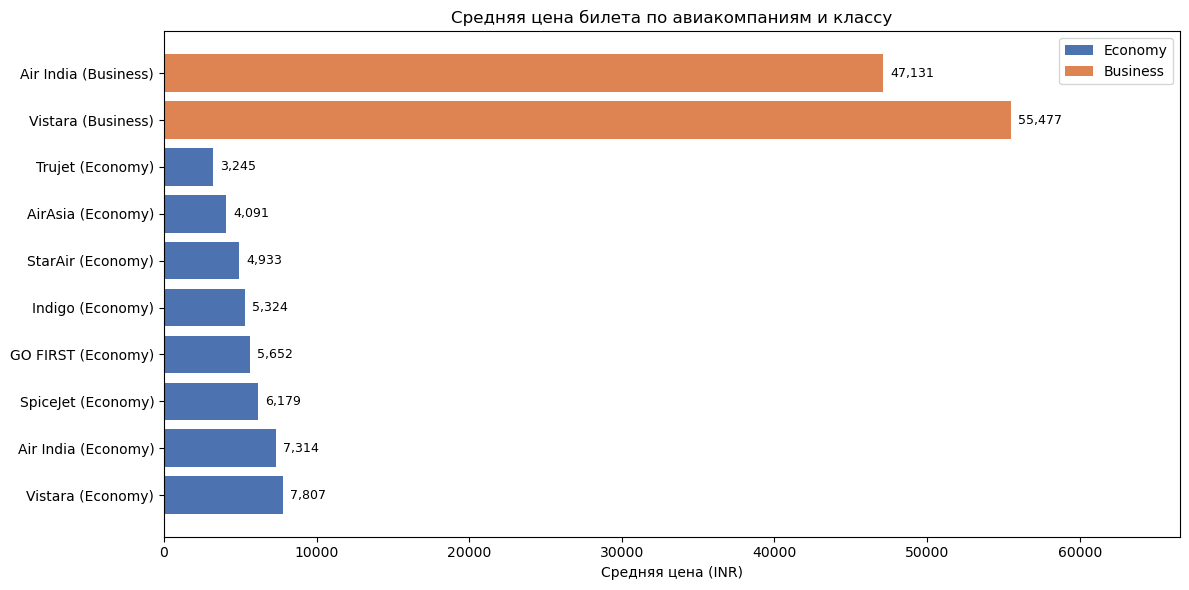

In [14]:
avg_price = df.groupby(['airline', 'class'])['price'].mean().reset_index()
avg_price = avg_price.sort_values('price', ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
colors = {'Economy': '#4C72B0', 'Business': '#DD8452'}

for cls in ['Economy', 'Business']:
    subset = avg_price[avg_price['class'] == cls]
    bars = ax.barh(subset['airline'] + f' ({cls})', subset['price'],
                   color=colors[cls], label=cls)
    ax.bar_label(bars, fmt=lambda x: f'{x:,.0f}', padding=5, fontsize=9)

ax.set_xlabel('Средняя цена (INR)')
ax.set_title('Средняя цена билета по авиакомпаниям и классу')
ax.legend()
ax.set_xlim(0, avg_price['price'].max() * 1.2)
plt.tight_layout()
plt.savefig('avg_price_by_airline.png', dpi=150)
plt.show()

**Вывод:** Vistara — самая дорогая авиакомпания в обоих классах (бизнес 55 477 INR, эконом 7 807 INR). Trujet и AirAsia — бюджетный сегмент, в 2 раза дешевле Vistara. Бизнес-класс в среднем в 7 раз дороже эконома.

### Инсайт 2: Динамика цен по датам (Delhi — Mumbai)

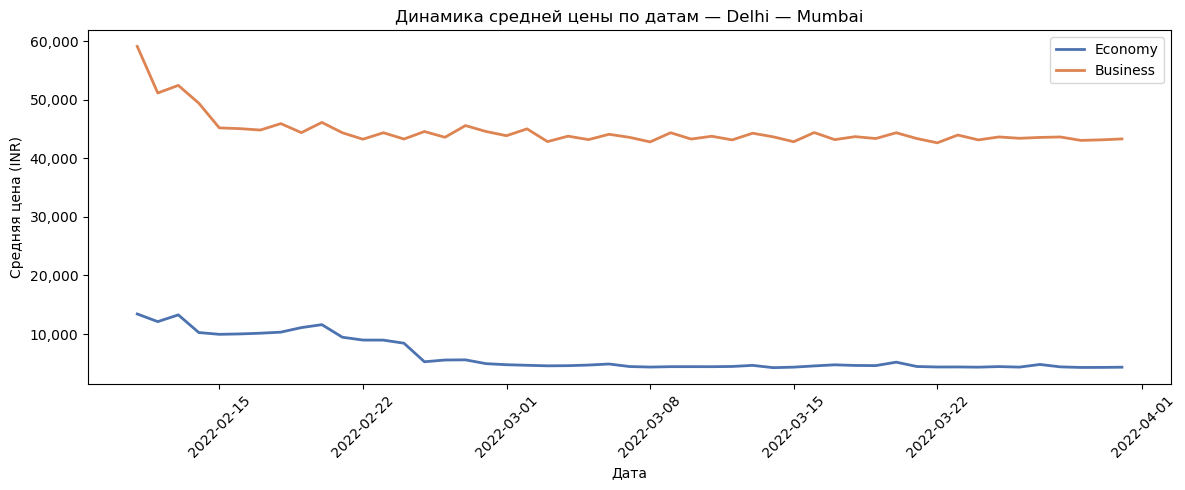

In [15]:
route = df[(df['from'] == 'Delhi') & (df['to'] == 'Mumbai')]
price_by_date = route.groupby(['date', 'class'])['price'].mean().reset_index()

fig, ax = plt.subplots(figsize=(12, 5))

for cls, color in [('Economy', '#4C72B0'), ('Business', '#DD8452')]:
    subset = price_by_date[price_by_date['class'] == cls]
    ax.plot(subset['date'], subset['price'], label=cls, color=color, linewidth=2)

ax.set_title('Динамика средней цены по датам — Delhi — Mumbai')
ax.set_xlabel('Дата')
ax.set_ylabel('Средняя цена (INR)')
ax.legend()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('price_dynamics_delhi_mumbai.png', dpi=150)
plt.show()

**Вывод:** На маршруте Delhi — Mumbai цены в начале периода в 2-3 раза выше чем в середине. Эконом падает с 13 000 до 5 000 INR, бизнес — с 60 000 до 43 000 INR. После 1 марта цены стабилизируются. Оптимальное окно покупки — 3-5 недель до вылета.

### Инсайт 3: Цена и количество пересадок

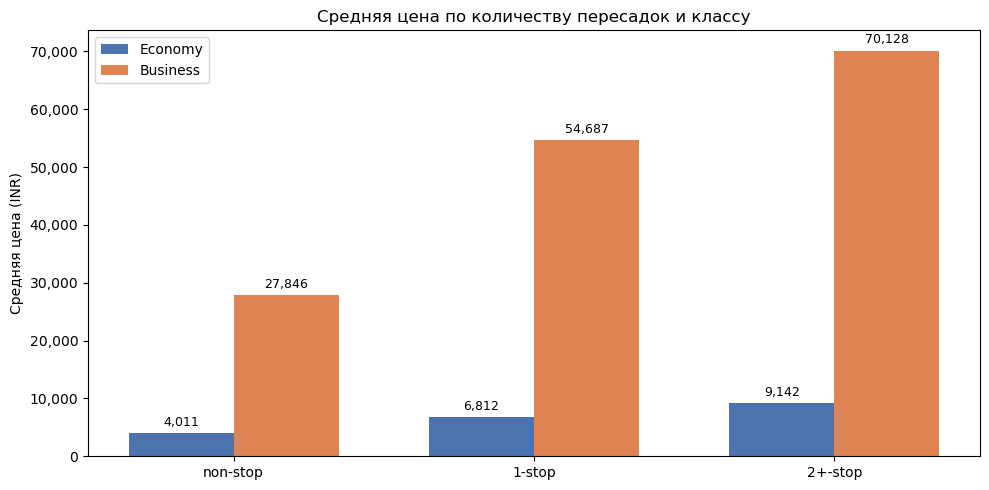

In [16]:
avg_by_stop = df.groupby(['stop', 'class'])['price'].mean().reset_index()

fig, ax = plt.subplots(figsize=(10, 5))
stop_order = ['non-stop', '1-stop', '2+-stop']
colors = {'Economy': '#4C72B0', 'Business': '#DD8452'}
x = range(len(stop_order))
width = 0.35

for i, cls in enumerate(['Economy', 'Business']):
    subset = avg_by_stop[avg_by_stop['class'] == cls].set_index('stop').reindex(stop_order)
    bars = ax.bar([xi + i * width for xi in x], subset['price'],
                  width=width, label=cls, color=colors[cls])
    ax.bar_label(bars, fmt=lambda v: f'{v:,.0f}', padding=3, fontsize=9)

ax.set_xticks([xi + width / 2 for xi in x])
ax.set_xticklabels(stop_order)
ax.set_title('Средняя цена по количеству пересадок и классу')
ax.set_ylabel('Средняя цена (INR)')
ax.legend()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.savefig('price_by_stops.png', dpi=150)
plt.show()

**Вывод:** Прямые рейсы дешевле рейсов с пересадками — в 2.3 раза в экономе (4 011 vs 9 142 INR) и в 2.5 раза в бизнесе (27 846 vs 70 128 INR). Контринтуитивный инсайт: пассажир платит больше не за комфорт, а за неудобство маршрута.

## 3. SQL-анализ

Загружаем данные в SQLite и демонстрируем владение оконными функциями и CTE.

Полные запросы: [queries.sql](queries.sql)

In [17]:
# Создаём базу данных SQLite
conn = sqlite3.connect('flights.db')
df.to_sql('flights', conn, if_exists='replace', index=False)

result = pd.read_sql('SELECT COUNT(*) as total FROM flights', conn)
print('Записей в базе:', result['total'][0])

Записей в базе: 300261


In [18]:
# Запрос 1: RANK — ранжирование авиакомпаний по цене внутри маршрута
query1 = """
SELECT 
    "from",
    "to",
    airline,
    ROUND(AVG(price), 0) AS avg_price,
    RANK() OVER (
        PARTITION BY "from", "to" 
        ORDER BY AVG(price) DESC
    ) AS price_rank
FROM flights
WHERE class = 'Economy'
GROUP BY "from", "to", airline
ORDER BY "from", "to", price_rank
"""
pd.read_sql(query1, conn).head(12)

,from,to,airline,avg_price,price_rank
0,Bangalore,Chennai,Air India,8219.0,1
1,Bangalore,Chennai,Vistara,7912.0,2
2,Bangalore,Chennai,GO FIRST,5352.0,3
3,Bangalore,Chennai,SpiceJet,2613.0,4
4,Bangalore,Chennai,Indigo,2363.0,5
5,Bangalore,Chennai,AirAsia,2073.0,6
6,Bangalore,Delhi,SpiceJet,6902.0,1
7,Bangalore,Delhi,Air India,6788.0,2
8,Bangalore,Delhi,Vistara,6506.0,3
9,Bangalore,Delhi,Indigo,6273.0,4


In [19]:
# Запрос 2: CTE + CASE WHEN — сегментация рейсов по ценовому уровню
query2 = """
WITH price_segments AS (
    SELECT 
        airline, class, price,
        CASE 
            WHEN price < 5000 THEN 'Бюджет'
            WHEN price BETWEEN 5000 AND 15000 THEN 'Средний'
            ELSE 'Премиум'
        END AS segment
    FROM flights
)
SELECT 
    segment,
    class,
    COUNT(*) AS flight_count,
    ROUND(AVG(price), 0) AS avg_price
FROM price_segments
GROUP BY segment, class
ORDER BY class, avg_price
"""
pd.read_sql(query2, conn)

,segment,class,flight_count,avg_price
0,Средний,Business,70,12265.0
1,Премиум,Business,93417,52570.0
2,Бюджет,Economy,81469,3617.0
3,Средний,Economy,117605,7845.0
4,Премиум,Economy,7700,18377.0


In [20]:
# Запрос 3: LAG — динамика изменения цены день к дню (Delhi — Mumbai, Economy)
query3 = """
WITH daily_price AS (
    SELECT 
        date,
        ROUND(AVG(price), 0) AS avg_price
    FROM flights
    WHERE "from" = 'Delhi' 
      AND "to" = 'Mumbai'
      AND class = 'Economy'
    GROUP BY date
)
SELECT 
    date,
    avg_price,
    LAG(avg_price) OVER (ORDER BY date) AS prev_day_price,
    ROUND(avg_price - LAG(avg_price) OVER (ORDER BY date), 0) AS price_change
FROM daily_price
ORDER BY date
"""
pd.read_sql(query3, conn)

,date,avg_price,prev_day_price,price_change
0,2022-02-11 00:00:00,13426.0,NaN,NaN
1,2022-02-12 00:00:00,12118.0,13426.0,-1308.0
2,2022-02-13 00:00:00,13273.0,12118.0,1155.0
3,2022-02-14 00:00:00,10258.0,13273.0,-3015.0
4,2022-02-15 00:00:00,9953.0,10258.0,-305.0
5,2022-02-16 00:00:00,10019.0,9953.0,66.0
6,2022-02-17 00:00:00,10144.0,10019.0,125.0
7,2022-02-18 00:00:00,10325.0,10144.0,181.0
8,2022-02-19 00:00:00,11101.0,10325.0,776.0
9,2022-02-20 00:00:00,11605.0,11101.0,504.0


## 4. A/B тест

**Гипотеза:** билеты в начале периода бронирования (группа A) статистически дороже чем в конце (группа B)

- **H0:** разницы в ценах нет
- **H1:** цены в группе A выше чем в группе B
- **Уровень значимости:** alpha = 0.05

In [21]:
# Группа A — первые 7 дней (11–17 февраля)
group_a = df[
    (df['date'] >= '2022-02-11') & 
    (df['date'] <= '2022-02-17') &
    (df['class'] == 'Economy')
]['price']

# Группа B — последние 7 дней (25–31 марта)
group_b = df[
    (df['date'] >= '2022-03-25') & 
    (df['date'] <= '2022-03-31') &
    (df['class'] == 'Economy')
]['price']

print(f'Группа A (ранние даты): n={len(group_a)}, mean={group_a.mean():,.0f} INR')
print(f'Группа B (поздние даты): n={len(group_b)}, mean={group_b.mean():,.0f} INR')

Группа A (ранние даты): n=21577, mean=11,631 INR
Группа B (поздние даты): n=30335, mean=4,792 INR


In [22]:
# T-тест (независимые выборки)
t_stat, p_value = stats.ttest_ind(group_a, group_b)

print(f't-статистика: {t_stat:.2f}')
print(f'p-value: {p_value:.10f}')
print()
if p_value < 0.05:
    print('Вывод: разница статистически значима — H0 отвергается, гипотеза подтверждена')
else:
    print('Вывод: разница не значима — H0 не отвергается')

t-статистика: 229.10
p-value: 0.0000000000

Вывод: разница статистически значима — H0 отвергается, гипотеза подтверждена


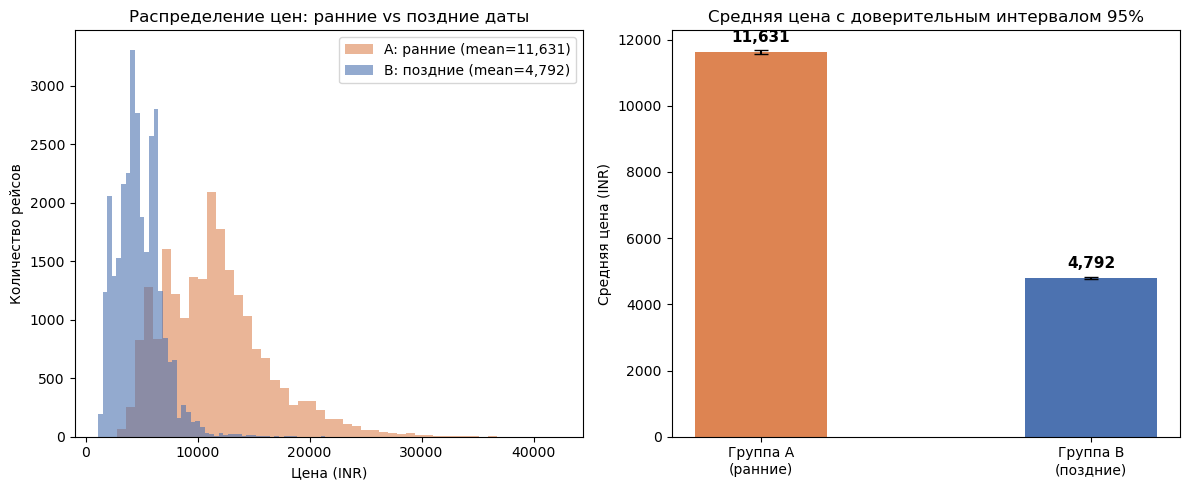

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# График 1 — распределение цен
axes[0].hist(group_a, bins=50, alpha=0.6, color='#DD8452', label=f'A: ранние (mean={group_a.mean():,.0f})')
axes[0].hist(group_b, bins=50, alpha=0.6, color='#4C72B0', label=f'B: поздние (mean={group_b.mean():,.0f})')
axes[0].set_title('Распределение цен: ранние vs поздние даты')
axes[0].set_xlabel('Цена (INR)')
axes[0].set_ylabel('Количество рейсов')
axes[0].legend()

# График 2 — средние с доверительным интервалом (95%)
means = [group_a.mean(), group_b.mean()]
errors = [group_a.sem() * 1.96, group_b.sem() * 1.96]
bars = axes[1].bar(['Группа A\n(ранние)', 'Группа B\n(поздние)'],
                    means, yerr=errors,
                    color=['#DD8452', '#4C72B0'],
                    capsize=5, width=0.4)
for bar, val in zip(bars, means):
    axes[1].text(bar.get_x() + bar.get_width() / 2, val + 200,
                f'{val:,.0f}', ha='center', va='bottom',
                fontsize=11, fontweight='bold', color='black')
axes[1].set_title('Средняя цена с доверительным интервалом 95%')
axes[1].set_ylabel('Средняя цена (INR)')

plt.tight_layout()
plt.savefig('ab_test_results.png', dpi=150)
plt.show()

**Вывод:** Гипотеза подтверждена. Разница в 2.4 раза (11 631 vs 4 792 INR) статистически значима — p-value практически равен нулю. Покупка билета в начале периода обходится пассажиру значительно дороже.

## Итог

| Направление | Находка | Значение |
|---|---|---|
| Авиакомпании | Vistara дороже бюджетных в 2 раза | Выбор перевозчика важнее класса |
| Динамика цен | Падение в 2-3 раза за первые 2 недели | Раннее бронирование невыгодно |
| Пересадки | Non-stop дешевле чем 1-stop | Контринтуитивный инсайт |
| A/B тест | p-value = 0, разница 2.4 раза | Гипотеза подтверждена |